# Phase 1: Download data

In [ ]:
from stackapi import StackAPI
import pandas as pd
import time
import os

def fetch_cs_data(target_count=5000000, csv_path = 'data/cs/cs_raw.csv'):
    key = 'rl_oEDaHHZDZpBQYbecJxwqdr3Ss'
    SITE = StackAPI('cs', key=key)
    SITE.page_size = 100
    
    data = []
    page = 1
    total_fetched = 0
    
    os.makedirs('data', exist_ok=True)
    
    
    while total_fetched < target_count:
        try:
            questions = SITE.fetch('questions', 
                                  page=page, 
                                  min=1, 
                                  sort='votes', 
                                  filter='withbody')
            
            if 'items' not in questions or not questions['items']:
                break
                
            batch_data = []
            for item in questions['items']:
                batch_data.append({
                    'title': item.get('title'),
                    'body': item.get('body'),
                    'tags': '|'.join(item.get('tags', []))
                })
            
            data.extend(batch_data)
            total_fetched += len(batch_data)
            print(f"Progress: {total_fetched}/{target_count} (Page {page})")
            
            if page % 100 == 0:
                df_batch = pd.DataFrame(data)
                df_batch.to_csv(csv_path, index=False, mode='a', header=not os.path.exists(csv_path))
                data = []
                
            page += 1
            time.sleep(0.1)
            
        except Exception as e:
            print(f"Stop at page {page}: {e}")
            break

    if data:
        pd.DataFrame(data).to_csv(csv_path, index=False, mode='a', header=not os.path.exists(csv_path))
        return csv_path

#path = fetch_cs_data(75000)

# Phase 2: EDA

## I. Data Exploring

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import pandas as pd
from sklearn.cluster import AgglomerativeClustering
df = pd.read_csv('data/cs/cs_raw.csv')
new_df = pd.read_csv('data/cs/cs_var.csv')

full_df = pd.concat([df,new_df],ignore_index=True)

In [6]:
df = full_df.copy().dropna()

### 1. Frequency and distribution

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os

def eda(df, out_dir='result/cs'):
    os.makedirs(out_dir, exist_ok=True)
    
    df['t_len'] = df['title'].apply(lambda x: len(str(x).split()))
    df['b_len'] = df['body'].apply(lambda x: len(str(x).split()))
    
    if not isinstance(df['tags'].iloc[0], list):
        df['tags'] = df['tags'].str.split('|')
    tags = []
    df['tags'].apply(lambda x: tags.extend(x) if isinstance(x, list) else None)  
    df['tags_count'] = df['tags'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    
    print("--- Stats ---")
    print(df[['t_len', 'b_len', 'tags_count']].describe())

    c = Counter(tags)
    
    print(f"\nUnique Tags: {len(c)}")
    print("Top 10:", c.most_common(10))
    
    plt.figure(figsize=(10, 5))
    sns.histplot(df['b_len'], bins=50, kde=True)
    plt.title('Body Length')
    plt.savefig(f'{out_dir}/b_dist.png')
    plt.show()
    plt.close()
    
    top_df = pd.DataFrame(c.most_common(20), columns=['tag', 'count'])
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_df, x='count', y='tag')
    plt.title('Top 20 Tags')
    plt.savefig(f'{out_dir}/t_dist.png')
    plt.show()
    plt.close()

    plt.figure(figsize=(10, 5))
    sns.histplot(df['tags_count'], bins=50, kde=True)
    plt.title('Body Length')
    plt.savefig(f'{out_dir}/b_dist.png')
    plt.show()
    plt.close()

KeyboardInterrupt: 

--- Stats ---
               t_len          b_len     tags_count
count  255305.000000  255305.000000  255305.000000
mean        9.370005     164.374955       2.683116
std         4.269028     138.126005       1.138897
min         1.000000       5.000000       1.000000
25%         6.000000      77.000000       2.000000
50%         9.000000     127.000000       3.000000
75%        12.000000     206.000000       3.000000
max        37.000000    2562.000000       5.000000

Unique Tags: 669
Top 10: [('algorithms', 63014), ('complexity-theory', 32371), ('graphs', 28300), ('formal-languages', 15113), ('time-complexity', 13478), ('turing-machines', 12570), ('data-structures', 11851), ('computability', 11463), ('optimization', 10687), ('algorithm-analysis', 10321)]


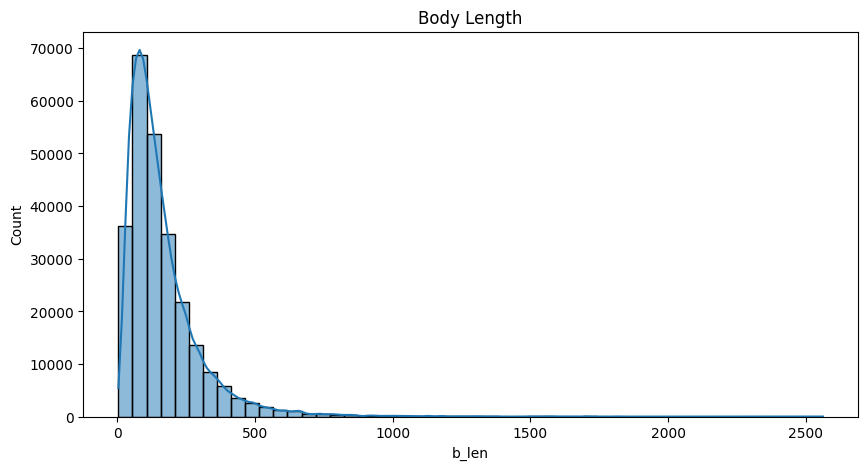

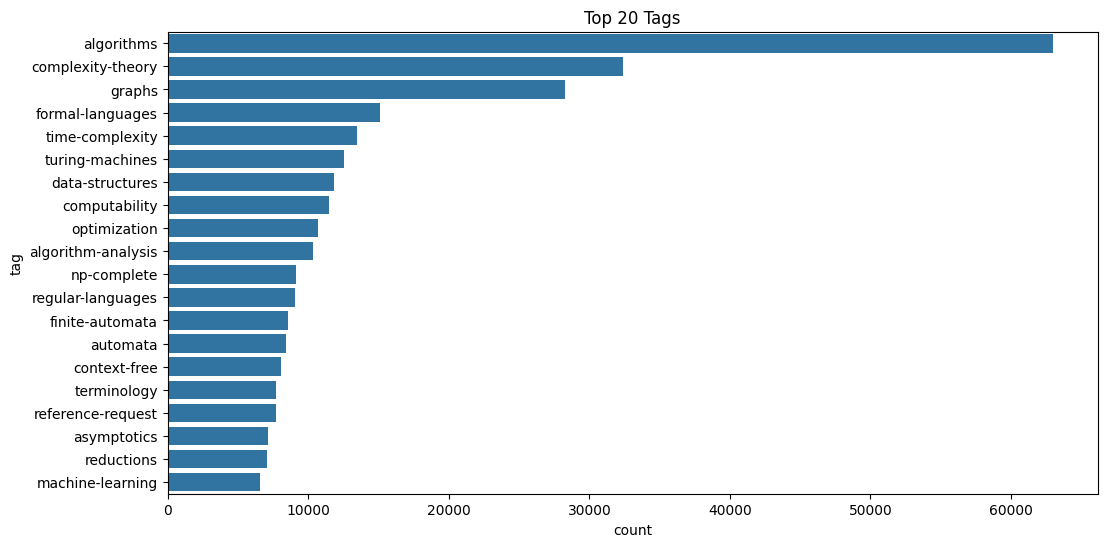

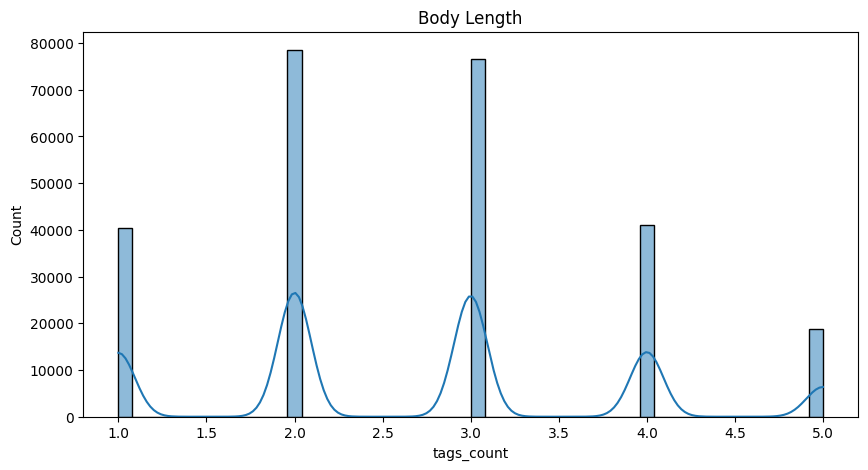

In [8]:
eda(df)

### 2. Correlations, visualizing tags relation

In [ ]:
import numpy as np
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer

def plot_tag(m, u_tags, target = "algorithms", top=30, out='result/cs/cov_matrix.png'):
    if target not in u_tags: return print(f"Tag {target} not found")
    
    v = np.sqrt(np.diag(m))
    v[v == 0] = 1e-9
    corr_m = m / np.outer(v, v)
    
    t2i = {t: i for i, t in enumerate(u_tags)}
    tid = t2i[target]
    
    row = corr_m[tid]
    idx = np.argsort(row)[::-1]
    rel_idx = idx[idx != tid][:top]
    
    sub_m = corr_m[np.ix_(rel_idx, rel_idx)].copy()
    t_sub = [u_tags[i] for i in rel_idx]
    
    for i, idx_val in enumerate(rel_idx):
        sub_m[i, i] = corr_m[idx_val, tid]
        
    plt.figure(figsize=(16, 13))
    sns.heatmap(sub_m, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, 
                xticklabels=t_sub, yticklabels=t_sub, square=True)
    plt.title(f'Target: "{target}" | Diagonal: Correlation with "{target}"')
    plt.savefig(out)
    plt.show()
    plt.close()

def plot_co(cov_m, u_tags, top_n=30, out='result/cs/co_matrix.png'):
    idx = np.argsort(np.diag(cov_m))[::-1][:top_n]
    m_sub = cov_m[np.ix_(idx, idx)]
    t_sub = [u_tags[i] for i in idx]
    
    plt.figure(figsize=(15, 12))
    sns.heatmap(m_sub, annot=False, cmap='RdBu_r', center=0, 
                xticklabels=t_sub, yticklabels=t_sub, square=True)
    plt.title(f'Top {top_n} Tag Covariance Matrix')
    
    os.makedirs(os.path.dirname(out), exist_ok=True)
    plt.savefig(out)
    plt.show()

def get_cov_matrix(df, plot = True):
    tag_lists = df['tags']
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(tag_lists)
    u_tags = mlb.classes_
    
    n = X.shape[0]

    sum_x = np.array(X.sum(axis=0)).flatten()
    dot_product = (X.T @ X).toarray() 
    
    cov_m = (dot_product / (n - 1)) - np.outer(sum_x, sum_x) / (n * (n - 1))
    if plot:
        plot_tag(cov_m, u_tags)
    return cov_m, u_tags

m, u_tags = get_cov_matrix(df)

NameError: name 'df' is not defined

### 3. Clustering tags, forming community

In [3]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

def get_subsumption(df, threshold=0.8):
    tag_lists = df['tags']
    mlb = MultiLabelBinarizer(sparse_output=True)
    X = mlb.fit_transform(tag_lists)
    u_tags = mlb.classes_
    
    counts = np.array(X.sum(axis=0)).flatten()
    co_matrix = (X.T @ X).toarray()
    
    prob_matrix = co_matrix / counts
    
    hierarchy = []
    for i, tag_b in enumerate(u_tags):
        for j, tag_a in enumerate(u_tags):
            if i != j and prob_matrix[j, i] >= threshold:
                if prob_matrix[i, j] < prob_matrix[j, i]:
                    hierarchy.append({'child': tag_b, 'parent': tag_a, 'conf': prob_matrix[j, i]})
                    
    return pd.DataFrame(hierarchy), co_matrix, u_tags

def get_communities(co_matrix, u_tags, min_weight=5):
    G = nx.Graph()
    for i in range(len(u_tags)):
        for j in range(i + 1, len(u_tags)):
            if co_matrix[i, j] >= min_weight:
                G.add_edge(u_tags[i], u_tags[j], weight=co_matrix[i, j])
    
    partition = community_louvain.best_partition(G, weight='weight')
    return partition

def analyze_hierarchy(df):
    sub_df, co_m, tags = get_subsumption(df)
    comm_map = get_communities(co_m, tags)
    
    res = []
    for tag in tags:
        res.append({
            'tag': tag,
            'community': comm_map.get(tag, -1),
            'is_root': tag in sub_df['parent'].values,
            'parent_candidate': sub_df[sub_df['child'] == tag]['parent'].tolist()[:3]
        })
        
    roots = sub_df.groupby('parent').size().sort_values(ascending=False)
    return pd.DataFrame(res), roots



In [11]:
res_df, root_stats = analyze_hierarchy(df)
print("--- Root Tags ---")
print(root_stats.head(5))
print("\n--- Sample Hierarchy ---")
print(res_df[res_df['is_root'] == False].head(10))

--- Root Tags ---
parent
graphs                    9
algorithms                7
computational-geometry    3
data-structures           3
neural-networks           3
dtype: int64

--- Sample Hierarchy ---
                      tag  community  is_root parent_candidate
0                   2-sat          0    False               []
2           a-star-search          1    False               []
3     abstract-data-types          2    False               []
4          access-control          4    False               []
5        adjacency-matrix          1    False         [graphs]
6               adversary          1    False               []
7                    agda          2    False               []
8   agent-based-computing          5    False               []
9                 algebra          2    False               []
11       algorithm-design          1    False               []


In [4]:
def get_rep_tags(m, u_tags, labels):
    unique_labels = np.unique(labels)
    rep_mapping = {}
    v = np.sqrt(np.diag(m))
    v[v == 0] = 1e-9
    corr_m = m / np.outer(v, v)
    for label in unique_labels:
        idx = np.where(labels == label)[0]
        if len(idx) == 0: continue
        sub_corr = corr_m[np.ix_(idx, idx)]
        centrality = sub_corr.sum(axis=1)
        best_idx = idx[np.argmax(centrality)]
        rep_mapping[label] = u_tags[best_idx]
    return rep_mapping

def analyze_clusters_hybrid(df, min_weight=1):
    sub_df, co_m, u_tags = get_subsumption(df)
    
    G = nx.Graph()
    G.add_nodes_from(u_tags)
    for i in range(len(u_tags)):
        for j in range(i + 1, len(u_tags)):
            if co_m[i, j] >= min_weight:
                G.add_edge(u_tags[i], u_tags[j], weight=co_m[i, j])
    
    partition = community_louvain.best_partition(G, weight='weight')
    
    v = np.sqrt(np.diag(co_m))
    v[v == 0] = 1e-9
    corr_m = co_m / np.outer(v, v)
    
    unique_comms = set(partition.values())
    louvain_rep_map = {}
    for c_id in unique_comms:
        idx = [i for i, t in enumerate(u_tags) if partition.get(t) == c_id]
        if not idx: continue
        sub_corr = corr_m[np.ix_(idx, idx)]
        louvain_rep_map[c_id] = u_tags[idx[np.argmax(sub_corr.sum(axis=1))]]

    cluster_counts = pd.Series(partition.values()).value_counts()
    k_opt = len(cluster_counts[cluster_counts > 1])
    if k_opt < 2: k_opt = 20
        
    dist_m = 1 - np.clip(corr_m, 0, 1)
    ac = AgglomerativeClustering(n_clusters=k_opt, metric='precomputed', linkage='average')
    ac_labels = ac.fit_predict(dist_m)
    
    ac_rep_map = get_rep_tags(co_m, u_tags, ac_labels)
    
    res_list = []
    for i, tag in enumerate(u_tags):
        l_id = partition.get(tag)
        a_id = ac_labels[i]
        res_list.append({
            'tag': tag,
            'ac_id': a_id,
            'ac_name': ac_rep_map.get(a_id),
            'louvain_id': l_id,
            'louvain_name': louvain_rep_map.get(l_id, "Isolated"),
            'is_root': tag in sub_df['parent'].values
        })
        
    res_df = pd.DataFrame(res_list)
    
    summary = res_df.groupby(['louvain_id', 'louvain_name']).size().reset_index(name='tag_count')
    summary = summary.sort_values('tag_count', ascending=False).reset_index(drop=True)
    
    return res_df, summary

In [13]:
res_df, detected_k = analyze_clusters_hybrid(df)

In [14]:
print("--- Cluster Analysis ---")
print(f"Detected Clusters: {detected_k.shape[0]}")
print(detected_k)


--- Cluster Analysis ---
Detected Clusters: 10
   louvain_id           louvain_name  tag_count
0           1             algorithms        235
1           6  programming-languages        128
2           4      operating-systems         94
3           5       formal-languages         71
4           2       machine-learning         66
5           0      complexity-theory         57
6           9            asymptotics         15
7           3             complexity          1
8           7           epistemology          1
9           8                pruning          1


In [15]:
print(len(res_df[res_df['louvain_name'] == "algorithms"]))
print(len(res_df[res_df['ac_name'] == "algorithms"]))

235
663


## II. Preprocess whole data, put it all togeter

In [23]:
from typing import Union
import os
import re

def filter_tags(df, ratio=0.001, filter=None):
    N = len(df)
    if ratio:
        threshold = int(N * ratio)
        
        all_tags = [t.strip() for tags in df['tags'] for t in (tags if isinstance(tags, list) else str(tags).split('|'))]
        tag_counts = pd.Series(all_tags).value_counts()
        valid_tags = set(tag_counts[tag_counts >= threshold].index)
        print(f"--- FLAT BASELINE SETUP (Ratio: {ratio}) ---")
        print(f"Calculated Threshold: {threshold} samples")
        print(f"Unique Tags Remaining: {len(valid_tags)} (Dropped {len(tag_counts) - len(valid_tags)})")
        print(f"Samples Maintained: {len(df)} / {N}")
    elif filter is not None:    
        valid_tags = filter
    else:
        df['filtered_tags'] = df['tags']
        all_tags = [t.strip() for tags in df['tags'] for t in (tags if isinstance(tags, list) else str(tags).split('|'))]
        tag_counts = pd.Series(all_tags).value_counts()
        valid_tags = set(tag_counts[tag_counts > 0].index)
        
        return df, sorted(list(valid_tags))
        
    def clean_func(tags):
            t_list = tags if isinstance(tags, list) else str(tags).split('|')
            return [t.strip() for t in t_list if t.strip() in valid_tags]
    
    df['filtered_tags'] = df['tags'].apply(clean_func)
    

    df = df[df['filtered_tags'].map(len) > 0].copy()
    
    
    
    return df, sorted(list(valid_tags))


def clean(text):
    text = re.sub(r'<code>(.*?)</code>', r' [CODE_START] \1 [CODE_END] ', str(text), flags=re.DOTALL)
    text = re.sub(r'<.*>', '', text)
    text = re.sub(r'</.*>', '', text)
    return re.sub(r'\s+', ' ', text).strip()

def get_comm(df):
    sub_df, co_m, u_tags = get_subsumption(df)
    partition = get_communities(co_m, u_tags, min_weight=1)
    
    v = np.sqrt(np.diag(co_m))
    v[v == 0] = 1e-9
    corr_m = co_m / np.outer(v, v)
    
    unique_ids = set(partition.values())
    rep_names = {}
    for c_id in unique_ids:
        indices = [i for i, t in enumerate(u_tags) if partition.get(t) == c_id]
        if not indices: continue
        sub_corr = corr_m[np.ix_(indices, indices)]
        centrality = sub_corr.sum(axis=1)
        rep_names[c_id] = u_tags[indices[np.argmax(centrality)]]
        
    return partition, rep_names

def prep(src, dst=None, ratio=0.001, filter = None):
    if isinstance(src, str):
        df = pd.read_csv(src).dropna()
    else:
        df = src.dropna()

    df['text'] = (df['title'] + " " + df['body']).apply(clean)
    if ratio:
        df, val_tags = filter_tags(df, ratio=ratio)
    else:
        df, val_tags = filter_tags(df, ratio=None, filter = filter)
    
    # Get Community Mapping
    mapping, names = get_comm(df)
    
    def map_to_multi_l1(tags):
        l1_ids = {mapping.get(t) for t in tags if mapping.get(t) is not None}
        return sorted(list(l1_ids))

    df['l1'] = df['filtered_tags'].apply(map_to_multi_l1)
    
    df['l1_name'] = df['l1'].apply(lambda ids: [names.get(i) for i in ids])

    if dst:
        if os.path.dirname(dst):
            os.makedirs(os.path.dirname(dst), exist_ok=True)
        df.to_csv(dst, index=False)
        
    return df, mapping, names, val_tags

In [ ]:
df, mapper, names, val_tags = prep(df, 'data/cs/full_cs.csv', ratio=None, filter = None)


In [26]:
df.head(3)

,title,body,tags,t_len,b_len,tags_count,text,filtered_tags,l1,l1_name
0,Why is quicksort better than other sorting alg...,<p>In a standard algorithms course we are taug...,"[algorithms, sorting]",10,358,2,Why is quicksort better than other sorting alg...,"[algorithms, sorting]",[1],[algorithms]
1,"What is the definition of P, NP, NP-complete a...",<p>I'm in a course about <em>computing</em> an...,"[complexity-theory, terminology, complexity-cl...",10,61,5,"What is the definition of P, NP, NP-complete a...","[complexity-theory, terminology, complexity-cl...","[0, 3, 5]","[complexity-theory, formal-languages, programm..."
2,Why is writing down mathematical proofs more f...,<p>I have noticed that I find it far easier to...,"[correctness-proof, mathematical-foundations, ...",12,602,3,Why is writing down mathematical proofs more f...,"[correctness-proof, mathematical-foundations, ...","[1, 3, 5]","[algorithms, formal-languages, programming-lan..."


In [ ]:
print(mapper)
print(names)

{'2-sat': 0, '3-sat': 0, 'algorithms': 1, 'complexity-theory': 0, 'constraint-programming': 0, 'constraint-satisfaction': 0, 'graphs': 1, 'np-complete': 0, 'np-hard': 0, 'polynomial-time': 0, 'probability-theory': 1, 'random-walks': 1, 'randomized-algorithms': 1, 'satisfiability': 0, 'time-complexity': 0, 'xor': 1, 'approximation': 1, 'asymptotics': 3, 'bayesian-network': 0, 'bipartite-graph': 1, 'boolean-algebra': 4, 'circuits': 0, 'co-np': 0, 'colorings': 1, 'complexity-classes': 0, 'computability': 6, 'computational-complexity': 0, 'decision-problem': 0, 'factoring': 0, 'greedy-algorithms': 1, 'heuristics': 1, 'kolmogorov-complexity': 6, 'logic': 4, 'maxsat': 0, 'normal-forms': 6, 'np': 0, 'optimization': 1, 'p-vs-np': 0, 'parameterized-complexity': 0, 'pedagogy': 5, 'polynomial-time-reductions': 0, 'probabilistic-algorithms': 1, 'proof-techniques': 6, 'quantum-computing': 0, 'reductions': 0, 'reference-request': 4, 'sat-solvers': 0, 'space-complexity': 0, 'subset-sum': 0, 'terminol

In [ ]:
for k,v in mapper.items():
    print(f"{k}", end=", ") if v == 5 else None

pedagogy, access-control, concurrency, memory-allocation, operating-systems, security, distributed-systems, parallel-computing, arithmetic, binary-arithmetic, computer-networks, cpu-cache, cryptography, error-estimation, lattices, memory-access, numerical-algorithms, os-kernel, performance, power-consumption, threads, virtual-memory, assembly, authentication, benchmarking, binary, blockchain, byzantine, clocks, communication-protocols, computer-algebra, computer-architecture, consensus, cpu-pipelines, critical-section, database-theory, databases, deadlocks, digital-circuits, encryption, fault-tolerance, floating-point, mapreduce, mathematical-software, memory-management, message-passing, multi-tasking, mutual-exclusion, number-formats, numeral-representations, numerical-analysis, one-way-functions, paging, peer-to-peer, process-scheduling, protocols, resource-allocation, rounding, storage, synchronization, voting, real-time, cpu, memory-hardware, mips, descriptive-complexity, high-perf

In [27]:
import pandas as pd
import numpy as np

def run_comprehensive_audit(df, mapper):
    results = []
    l3_counts = []
    
    for _, row in df.iterrows():
        assigned = row['l1']
        assigned_set = {assigned} if not isinstance(assigned, (list, set, np.ndarray)) else set(assigned)
        
        raw_tags = row['tags']
        tag_list = raw_tags if isinstance(raw_tags, list) else str(raw_tags).split('|')
        tag_list = [t.strip() for t in tag_list if t.strip()]
        
        actual_l1_from_tags = {mapper.get(t) for t in tag_list if mapper.get(t) is not None}
        
        matches = [mapper.get(t) in assigned_set for t in tag_list if mapper.get(t) is not None]
        num_matches = sum(matches)
        total_valid_tags = len(matches)
        
        l3_counts.append(len(tag_list))
        results.append({
            'n_l3': len(tag_list),
            'n_l1_actual': len(actual_l1_from_tags),
            'is_fully_consistent': num_matches == total_valid_tags if total_valid_tags > 0 else True,
            'mismatch_count': total_valid_tags - num_matches
        })

    res_df = pd.DataFrame(results)
    l3_series = pd.Series(l3_counts)
    l1_actual_series = res_df['n_l1_actual']

    print("--- GLOBAL TAG (L3) STATISTICS ---")
    print(f"Mean L3 per Question: {l3_series.mean():.4f}")
    print(f"Std L3 per Question: {l3_series.std():.4f}")
    print(f"Min/Max L3 per Question: {l3_series.min()} / {l3_series.max()}")

    print("\n--- ACTUAL CLUSTER (L1) DISTRIBUTION (FROM TAGS) ---")
    print(f"Mean L1 per Question: {l1_actual_series.mean():.4f}")
    print(f"Std L1 per Question: {l1_actual_series.std():.4f}")
    print(f"Ratio L1 > 1 (Multi-disciplinary): {(l1_actual_series > 1).mean()*100:.2f}%")
    print(f"Ratio L1 == 0 (Unmapped): {(l1_actual_series == 0).mean()*100:.2f}%")
    print(f"Max L1 clusters in a single Question: {l1_actual_series.max()}")

    print("\n--- HIERARCHY CONSISTENCY ANALYSIS ---")
    print(f"Fully Consistent Questions: {res_df['is_fully_consistent'].mean()*100:.2f}%")
    
    total_mismatches = res_df['mismatch_count'].sum()
    total_tags_processed = l3_series.sum()
    print(f"Total Tags Mismatched with Assigned L1: {total_mismatches}")
    print(f"Tag-level Error Rate: {(total_mismatches / total_tags_processed)*100:.2f}%")

    return res_df

audit_results = run_comprehensive_audit(df, mapper)

--- GLOBAL TAG (L3) STATISTICS ---
Mean L3 per Question: 2.6831
Std L3 per Question: 1.1389
Min/Max L3 per Question: 1 / 5

--- ACTUAL CLUSTER (L1) DISTRIBUTION (FROM TAGS) ---
Mean L1 per Question: 1.4388
Std L1 per Question: 0.6179
Ratio L1 > 1 (Multi-disciplinary): 37.58%
Ratio L1 == 0 (Unmapped): 0.01%
Max L1 clusters in a single Question: 5

--- HIERARCHY CONSISTENCY ANALYSIS ---
Fully Consistent Questions: 100.00%
Total Tags Mismatched with Assigned L1: 0
Tag-level Error Rate: 0.00%


## II. Training

In [ ]:
from sklearn.metrics import classification_report, hamming_loss, accuracy_score, ndcg_score
from tabulate import tabulate
import pandas as pd
import numpy as np
import os
import torch
from tqdm import tqdm

def eval(model, loader, mlb, device, thres=0.3, active_head='l3', filename="result/cs/report/report.csv"):
    model.eval()
    all_scores, all_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            if len(batch) == 3:
                ids, mask, y = batch[0].to(device).long(), batch[1].to(device).long(), batch[2].to(device).float()
            else:
                ids, y = batch[0].to(device).float(), batch[1].to(device).float()
                mask = (ids != 0).to(device).long()
            # Additional head for Trans
            if type(model).__name__ == 'Trans': 
                outputs = model(ids, mask, active_head=active_head)[active_head]
            else:
                ids = ids.float()
                out = model(ids)
                outputs = out['l3'] if isinstance(out, dict) else out
            
            scores = torch.sigmoid(outputs).cpu().numpy()
            
            all_scores.append(scores)
            
            all_targets.append(y.cpu().numpy())
            
    y_score = np.vstack(all_scores)
    y_true = np.vstack(all_targets)
    y_pred = (y_score > thres).astype(int)
    
    report_dict = classification_report(y_true, y_pred, target_names=mlb.classes_, output_dict=True, zero_division=0)
    h_loss = hamming_loss(y_true, y_pred)
    sub_acc = accuracy_score(y_true, y_pred)
    ndcg_5 = ndcg_score(y_true, y_score, k=5)
    
    metrics = ['micro avg', 'macro avg', 'weighted avg', 'samples avg']
    table_data = [[m.upper()] + [report_dict[m][k] for k in ['precision', 'recall', 'f1-score', 'support']] for m in metrics]
    
    basic_tab = tabulate(table_data, headers=['GLOBAL METRIC', 'PRECISION', 'RECALL', 'F1-SCORE', 'SUPPORT'], tablefmt='fancy_grid')
    
    additional_metrics = [
        ["Subset Accuracy", f"{sub_acc:.4f}"],
        ["Hamming Loss", f"{h_loss:.4f}"],
        ["nDCG@5 (Ranking)", f"{ndcg_5:.4f}"]
    ]
    extra_tab = tabulate(additional_metrics, tablefmt='fancy_grid')

    df_report = pd.DataFrame(report_dict).transpose()
    df_report.loc['hamming_loss'] = [h_loss] * 3 + [y_true.shape[0]]
    df_report.loc['subset_accuracy'] = [sub_acc] * 3 + [y_true.shape[0]]
    df_report.loc['ndcg_at_5'] = [ndcg_5] * 3 + [y_true.shape[0]]
    
    if filename:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        df_report.to_csv(filename, index=True, encoding='utf-8-sig')
    
    return df_report, basic_tab, extra_tab

# Phase 4: Training Transformer

## I. Set up training

### 1. Attention Heads
XMC (Extreme Multilabel Classification) study proves that transformer models struggle to map the output to a large amount of labels. Traditional methods such as Global Pooling cause lost of information to minority labels, causing Tail Label Vanishing, aka Label Bias (model only optimize popular labels)

To better perform multilabel classification with > 300 classes, we propose label-wise-attention head. Different from self attention which capture semantic relations within itself - text to text semantic within an unit of context (paragraphs, usually), the Label-wise Attention is the Multihead Attention, each head capturing semantic from the text that correlates to the target label (text-label attention block). Those attention head will help the model remains attentive to key features that can relate to a tag, rather than scatter the attention span across a whole long paragraph

Source of references are XR-Transformer, MatchXML and AttentionXML. They are prime candidates for this method (but going through multiphase training since they got > 10k labels). Achieve SOTA in 2021 (AttentionXML), 2022 (XR-Transformer) and 2024 (MatchXML), only arguably exceeded by PRIME in 2025 with Hard Negative Mining method, creating suficient batches of Label-to-Prototype. However, since PRIME uses Triplet Loss, requiring massive training resources and time, I wont apply that for the sake of my computer

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel

class MaxHead(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.fc = nn.Linear(dim, num_labels)

    def forward(self, x):
        x = torch.max(x, dim=1)[0]
        return self.fc(x)

class GlobalAttention(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(dim, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        self.fc = nn.Linear(dim, num_labels)

    def forward(self, x):
        e = self.proj(x)
        w = F.softmax(e.squeeze(-1), dim=1)
        c = (x * w.unsqueeze(-1)).sum(dim=1)
        return self.fc(c)

class LabelWiseAttention(nn.Module):
    def __init__(self, dim, num_labels):
        super().__init__()
        self.q = nn.Parameter(torch.randn(num_labels, dim))
        self.fc = nn.Linear(dim, 1)

    def forward(self, x):
        q = self.q.to(x.dtype)

        att = torch.matmul(x, q.transpose(0, 1))
        att = F.softmax(att, dim=1)
        out = torch.matmul(att.transpose(1, 2), x)
        return self.fc(out).squeeze(-1)

### 2. Transformer
- Use all-MiniLM-L6-v2 for lightweight. Future improvement with BERT or RoBERTa are on hold, as referenced from previous SOTA

In [7]:
from transformers import AutoModel

class Trans(nn.Module):
    def __init__(self, model_name='sentence-transformers/all-MiniLM-L6-v2', device=None):
        super().__init__()
        self.device = device if device else ('cuda' if torch.cuda.is_available() else 'cpu')
        self.transformer = AutoModel.from_pretrained(model_name)
        self.dim = self.transformer.config.hidden_size
        self.heads = nn.ModuleDict()
        self.to(self.device)
        self.f1 = 0.0

    def add_head(self, name, head_type, num_labels):
        if head_type == 'lwa':
            self.heads[name] = LabelWiseAttention(self.dim, num_labels)
        elif head_type == 'global':
            self.heads[name] = GlobalAttention(self.dim, num_labels)
        elif head_type == 'max':
            self.heads[name] = MaxHead(self.dim, num_labels)
        else:
            raise ValueError(f"Head type {head_type} is not supported!")
        self.heads[name].to(self.device)

    def forward(self, input_ids, attention_mask, active_head='l3'):
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)
        lhs = outputs.last_hidden_state
        
        if active_head == 'all':
            return {name: head(lhs) for name, head in self.heads.items()}
        
        return {active_head: self.heads[active_head](lhs)}
    def load_checkpoint(self, path):
     
        checkpoint = torch.load(path, map_location=self.device, weights_only=False)
        
        # Full Customized Dict
        if isinstance(checkpoint, dict) and 'model_state' in checkpoint:
            self.load_state_dict(checkpoint['model_state'])
            thres = checkpoint.get('best_threshold', 0.3)
            self.f1 = checkpoint.get('f1', checkpoint.get('macro_f1', 0.0))
            print(f"--> [SUCCESS] Loaded Model. Best Threshold: {thres} | Best F1: {f1:.4f}")
            return thres 
            
        # State_dict
        else:
            self.load_state_dict(checkpoint)
            print(f"--> [SUCCESS] Loaded Raw State Dict. Threshold defaults to 0.3")
            return 0.3

## 3. Loss

In [60]:
import torch.nn.functional as F

def get_cb_weights(df, mlb, beta=0.999):
    """
    A simple weight assigning formula: W = (1 - beta)/(1 - beta^n)
    Satisfy: f'(x1) < f'(x2)
    """
   
    tag_counts = df['tags'].explode().value_counts()
    
    
    samples_per_class = np.array([tag_counts.get(cls, 0) for cls in mlb.classes_])
    
    e = 1.0 - np.power(beta, samples_per_class)
    
    weights = (1.0 - beta) / np.where(e == 0, 0.01, e)
    
    #weights = weights / np.sum(weights) * len(mlb.classes_)
    #weights = np.power(weights, 0.67)
    weights = weights / np.min(weights) # Normalize: min_weight = min_weight/min_weight = 1
    
    print(f"--> Min Weight (Head): {np.min(weights):.4f}")
    print(f"--> Max Weight (Tail): {np.max(weights):.4f}")
    print(f"--> Average Weight: {np.average(weights):.4f}")
    return torch.tensor(weights, dtype=torch.float)

class ASLCB(nn.Module):
    def __init__(self, gamma_neg=2, gamma_pos=0.0, clip=0.05, cb_weights=None):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.cb_weights = cb_weights # Tensor (662,)

    def forward(self, x, y):
        # x: logits, y: targets
        xs_pos = torch.sigmoid(x)
        xs_neg = 1 - xs_pos

        # Asymmetric Clipping
        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        # Basic BCE
        loss_pos = y * torch.log(xs_pos.clamp(min=1e-8))
        loss_neg = (1 - y) * torch.log(xs_neg.clamp(min=1e-8))
        loss = - (loss_pos + loss_neg)

        # Asymmetric Focusing
        final_weight = torch.where(y > 0.5, 
                                   torch.pow(1 - xs_pos, self.gamma_pos), 
                                   torch.pow(1 - xs_neg, self.gamma_neg))
        loss *= final_weight

        # Apply Class-Balanced weights
        if self.cb_weights is not None:
            loss *= self.cb_weights.to(x.device)

        return loss.mean()

In [ ]:
import gc 
from sklearn.metrics import f1_score, hamming_loss

def best_thres(model, val_loader, mlb, device, active_head='l3', max_t=0.85):
    model.eval()
    all_probs, all_targets = [], []
    
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Predicting"):
            ids = batch[0].to(device).long()
            mask = batch[1].to(device) if len(batch) == 3 else (ids != 0).to(device).long()
            y = batch[2].cpu().numpy() if len(batch) == 3 else batch[1].cpu().numpy()
            
            outputs = model(ids, mask, active_head=active_head)[active_head]
            all_probs.append(torch.sigmoid(outputs).cpu().numpy().astype(np.float32))
            all_targets.append(y.astype(np.uint8))
            
    y_probs = np.vstack(all_probs)
    y_true = np.vstack(all_targets)
    
    del all_probs, all_targets
    gc.collect() 
    
    best_t, best_f1 = 0.3, 0
    for t in np.round(np.arange(0.1, max_t + 0.05, 0.05), 2):
        y_pred = (y_probs > t).astype(np.uint8)
        ma_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        
        if ma_f1 > best_f1:
            best_f1, best_t = ma_f1, t
        
        del y_pred
        
    gc.collect() 
    
    report = classification_report(y_true, (y_probs > best_t).astype(np.uint8), 
                                   target_names=mlb.classes_, output_dict=True, zero_division=0)
    
    metrics = ['micro avg', 'macro avg', 'weighted avg', 'samples avg']
    table_data = [[m.upper()] + [report[m][k] for k in ['precision', 'recall', 'f1-score', 'support']] for m in metrics]
    basic_tab = tabulate(table_data, headers=['GLOBAL METRIC', 'PRECISION', 'RECALL', 'F1-SCORE', 'SUPPORT'], tablefmt='fancy_grid')
    
    return best_t, basic_tab, best_f1

In [ ]:
import torch, os, gc
from torch.optim import AdamW
from torch.amp import GradScaler, autocast
from tqdm import tqdm

def train_transformer(model, train_loader, val_loader, mlb, device, head_name='l3',cb_weights = None, epochs=10,weight = 3.0, train_with_wu = True, acc_steps=2, name="trans_lwa"):
    if cb_weights is not None:
        criterion = ASLCB(cb_weights=cb_weights)
        print("--> Using Asymmetric Loss with Class-Balanced weights")
    else:
        criterion = torch.nn.BCEWithLogitsLoss()
    scaler = GradScaler()
    best_f1 = model.f1
    warm_up = min(max(int(epochs/2)+1, 0), 7) if train_with_wu else 0

    max_t = 0.7
    for epoch in range(epochs):
        if (epoch < warm_up or (epoch%16>0 and epoch%16<3)) and train_with_wu:
            for param in model.transformer.parameters():
                param.requires_grad = False
            lr_backbone = 0.0
            lr_head = 1e-3
            desc = f"Warmup {epoch+1}/{epochs}"
        else:
            for param in model.transformer.parameters():
                param.requires_grad = True
            lr_backbone = 1e-4
            lr_head = 1e-3
            desc = f"Fine-tune {epoch+1}/{epochs}"

        optimizer = AdamW([
            {'params': model.transformer.parameters(), 'lr': lr_backbone},
            {'params': model.heads[head_name].parameters(), 'lr': lr_head}
        ], weight_decay=0.01)

        model.train()
        optimizer.zero_grad()
        pbar = tqdm(train_loader, desc=desc)
        
        for i, batch in enumerate(pbar):
            if len(batch) == 3:
                ids, mask, y = batch[0].to(device).long(), batch[1].to(device).long(), batch[2].to(device).float()
            else:
                ids, y = batch[0].to(device).long(), batch[1].to(device).float()
                mask = (ids != 0).to(device).long()

            with autocast(device_type='cuda'):
                outputs = model(ids, mask, active_head=head_name)[head_name]
                loss = criterion(outputs, y) / acc_steps
            
            scaler.scale(loss).backward()
            
            if (i + 1) % acc_steps == 0 or (i + 1) == len(train_loader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            pbar.set_postfix({'loss': f"{loss.item() * acc_steps:.4f}"})
            del ids, mask, y, outputs, loss

        cur_t, tab, curr_f1 = best_thres(model, val_loader, mlb, device, active_head=head_name)
        print(f"================== Epoch {epoch + 1} with t = {cur_t} ==================")
        print(tab)
        
        if curr_f1 > best_f1:
            best_f1 = curr_f1
            os.makedirs("model/weight/cs/", exist_ok=True)
            save_path = f"model/weight/cs/{name}_{head_name}_best.pt"
            torch.save({
                'model_state': model.state_dict(),
                'best_threshold': cur_t,
                'macro_f1': best_f1
            }, save_path)
            print(f"--> Saved: {save_path} (F1: {best_f1:.4f})")
        else: print(f"====> This epoch F!: {curr_f1} ")
        torch.cuda.empty_cache()
        gc.collect()

    return model

## II. Model Implementation

### 1. Traditional Transformer 

A commonly used transformer with MaxHead on top of pretrained model to support classification task

In [ ]:
import joblib
mlb_full = MultiLabelBinarizer(classes=val_tags)
mlb_full.fit([val_tags]) 
print(mlb_full.classes_)
joblib.dump(mlb_full, 'data/cs/full_mlb.pkl')
print(len(mlb_full.classes_))

['2-sat' '3-sat' 'a-star-search' 'abstract-data-types' 'access-control'
 'adjacency-matrix' 'adversary' 'agda' 'agent-based-computing' 'algebra'
 'algorithm-analysis' 'algorithm-design' 'algorithms' 'ambiguity'
 'amortized-analysis' 'answer-set-programming' 'api-design' 'applications'
 'applied-theory' 'approximation' 'approximation-algorithms' 'arithmetic'
 'arrays' 'artificial-intelligence' 'assembly' 'assignment-problem'
 'asymptotics' 'attribute-grammars' 'authentication' 'automata'
 'automated-theorem-proving' 'average-case' 'avl-trees' 'b-method'
 'b-tree' 'backtracking' 'balanced-search-trees' 'balls-and-bins'
 'base-conversion' 'bayesian-network' 'bayesian-statistics' 'bdd'
 'benchmarking' 'big-data' 'big-o-notation' 'binary' 'binary-arithmetic'
 'binary-search' 'binary-search-trees' 'binary-trees'
 'bio-inspired-computing' 'bioinformatics' 'bipartite-graph'
 'bipartite-matching' 'bit-blasting' 'bit-manipulation' 'blockchain'
 'bloom-filters' 'board-games' 'boltzmann-machine' '

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import torch
from torch.utils.data import TensorDataset, DataLoader
from skmultilearn.model_selection import IterativeStratification
from sklearn.metrics import f1_score, hamming_loss
import torch
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from tqdm import tqdm

y = mlb_full.transform(df['filtered_tags'])
stratifier = IterativeStratification(n_splits=2, order=1, sample_distribution_per_fold=[0.2, 0.8])
train_idx, val_idx = next(stratifier.split(df.index.values.reshape(-1, 1), y))

train_df = df.iloc[train_idx]
val_df = df.iloc[val_idx]

train_df.to_csv('data/cs/cs_full_train.csv', index=False)
val_df.to_csv('data/cs/cs_full_val.csv', index=False)

In [ ]:
import pandas as pd
import joblib
import torch
from torch.utils.data import TensorDataset, DataLoader
from transformers import AutoTokenizer
import ast


mlb = joblib.load('data/cs/full_mlb.pkl')
print(f"Loaded MLB with {len(mlb.classes_)} classes.")

train_df = pd.read_csv('data/cs/cs_var_train.csv')
val_df = pd.read_csv('data/cs/cs_var_val.csv')

tokenizer = AutoTokenizer.from_pretrained('sentence-transformers/all-MiniLM-L6-v2')

def prepare_transformer_loader(df, mlb, tokenizer, batch_size=16, shuffle=False):
    if isinstance(df['filtered_tags'].iloc[0], str):
        print("Phát hiện dữ liệu dạng string, đang convert sang list...")
        tags_list = df['filtered_tags'].apply(ast.literal_eval).tolist()
    else:
        tags_list = df['filtered_tags'].tolist()
    y = torch.tensor(mlb.transform(tags_list), dtype=torch.float32)
    
    encoded = tokenizer(
        df['text'].fillna("").tolist(), 
        padding='max_length', 
        truncation=True, 
        max_length=512, 
        return_tensors='pt'
    )
    
    dataset = TensorDataset(
        encoded['input_ids'], 
        encoded['attention_mask'], 
        y
    )
    
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

new_train = prepare_transformer_loader(train_df, mlb, tokenizer, batch_size=16, shuffle=True)
new_val = prepare_transformer_loader(val_df, mlb, tokenizer, batch_size=16, shuffle=False)

print("===================================================================")
print(f"Ready for Trans: Train {len(train_df)} | Val {len(val_df)}")

Loaded MLB with 669 classes.
Phát hiện dữ liệu dạng string, đang convert sang list...
Phát hiện dữ liệu dạng string, đang convert sang list...
Ready for Trans: Train 141356 | Val 34869


In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trans_lwa = Trans(device=dev)

cb_w = get_cb_weights(df, mlb,0.999)
# Basic loss: 0.45 Macro F1 after 23 epoch, all other stat ~ 0.9
trans_lwa.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa = train_transformer(trans_lwa, new_train, new_val, mlb, dev, 
                          epochs=30, 
                          cb_weights=cb_w,
                          weight = 3.0,
                          name="full_cs_cb_lwa")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Predicting: 100%|██████████| 2180/2180 [02:16<00:00, 15.96it/s]


================== Epoch 1 with t = 0.1 ==================
╒═════════════════╤═════════════╤═══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │    RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪═══════════╪════════════╪═══════════╡
│ MICRO AVG       │  0.059306   │ 0.402826  │  0.10339   │     89736 │
├─────────────────┼─────────────┼───────────┼────────────┼───────────┤
│ MACRO AVG       │  0.00921718 │ 0.0533551 │  0.0148013 │     89736 │
├─────────────────┼─────────────┼───────────┼────────────┼───────────┤
│ WEIGHTED AVG    │  0.0653698  │ 0.402826  │  0.110015  │     89736 │
├─────────────────┼─────────────┼───────────┼────────────┼───────────┤
│ SAMPLES AVG     │  0.0785627  │ 0.405711  │  0.117567  │     89736 │
╘═════════════════╧═════════════╧═══════════╧════════════╧═══════════╛
--> Saved: model/weight/full_cs_lwa_l3_best.pt (F1: 0.0148)


Predicting: 100%|██████████| 2180/2180 [02:18<00:00, 15.70it/s]


================== Epoch 2 with t = 0.15 ==================
╒═════════════════╤═════════════╤═══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │    RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪═══════════╪════════════╪═══════════╡
│ MICRO AVG       │   0.111842  │ 0.429504  │  0.177471  │     89736 │
├─────────────────┼─────────────┼───────────┼────────────┼───────────┤
│ MACRO AVG       │   0.0241099 │ 0.0613708 │  0.0303712 │     89736 │
├─────────────────┼─────────────┼───────────┼────────────┼───────────┤
│ WEIGHTED AVG    │   0.102804  │ 0.429504  │  0.158555  │     89736 │
├─────────────────┼─────────────┼───────────┼────────────┼───────────┤
│ SAMPLES AVG     │   0.129585  │ 0.430145  │  0.180353  │     89736 │
╘═════════════════╧═════════════╧═══════════╧════════════╧═══════════╛
--> Saved: model/weight/full_cs_lwa_l3_best.pt (F1: 0.0304)


...

Predicting: 100%|██████████| 2180/2180 [02:15<00:00, 16.06it/s]


================== Epoch 21 with t = 0.85 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.930764 │ 0.924623 │   0.927683 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.442976 │ 0.44036  │   0.439614 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.934482 │ 0.924623 │   0.927809 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.926909 │ 0.923638 │   0.915409 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.4396142967196069 


Predicting: 100%|██████████| 2180/2180 [02:16<00:00, 15.94it/s]


================== Epoch 22 with t = 0.85 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.915798 │ 0.94671  │   0.930998 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.441204 │ 0.447498 │   0.442701 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.91884  │ 0.94671  │   0.931088 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.919243 │ 0.943994 │   0.922945 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.4427009542381098 


Predicting: 100%|██████████| 2180/2180 [02:17<00:00, 15.80it/s]


In [61]:
import gc

gc.collect()
torch.cuda.empty_cache()
dev = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trans_lwa = Trans(device=dev)

cb_w = get_cb_weights(train_df, mlb)
# Basic loss: 0.45 Macro F1 after 23 epoch, all other stat ~ 0.9
trans_lwa.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


--> Min Weight (Head): 1.0000
--> Max Weight (Tail): 916.0252
--> Average Weight: 82.8156


In [65]:
trans_lwa = train_transformer(trans_lwa, new_train, new_val, mlb, dev, 
                          epochs=30, 
                          cb_weights=cb_w,
                          weight = 3.0,
                          name="full_cs_cb_lwa")

--> Using Asymmetric Loss with Class-Balanced weights


Predicting: 100%|██████████| 2180/2180 [02:13<00:00, 16.32it/s]


================== Epoch 1 with t = 0.35 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │   0.236302  │ 0.422874 │  0.303184  │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │   0.0761219 │ 0.120798 │  0.0817694 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │   0.213289  │ 0.422874 │  0.260013  │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │   0.247494  │ 0.426998 │  0.279959  │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/full_cs_cb_lwa_l3_best.pt (F1: 0.0818)


Predicting: 100%|██████████| 2180/2180 [02:13<00:00, 16.31it/s]


================== Epoch 2 with t = 0.35 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │   0.265175  │ 0.559073 │   0.359727 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │   0.0979867 │ 0.179909 │   0.11623  │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │   0.270355  │ 0.559073 │   0.348853 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │   0.298886  │ 0.573966 │   0.355066 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/full_cs_cb_lwa_l3_best.pt (F1: 0.1162)


...

================== Epoch 28 with t = 0.8 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.873047 │ 0.732248 │   0.796473 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.447601 │ 0.422495 │   0.432482 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.863586 │ 0.732248 │   0.782098 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.844422 │ 0.745831 │   0.765087 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/full_cs_cb_lwa_l3_best.pt (F1: 0.4325)


Predicting: 100%|██████████| 2180/2180 [02:29<00:00, 14.62it/s]


================== Epoch 29 with t = 0.75 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.877112 │ 0.737162 │   0.801071 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.450891 │ 0.419812 │   0.432012 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.869963 │ 0.737162 │   0.78868  │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.848006 │ 0.750358 │   0.77039  │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
====> This epoch F!: 0.43201202441837666 


Predicting: 100%|██████████| 2180/2180 [02:20<00:00, 15.50it/s]


================== Epoch 30 with t = 0.85 ==================
╒═════════════════╤═════════════╤══════════╤════════════╤═══════════╕
│ GLOBAL METRIC   │   PRECISION │   RECALL │   F1-SCORE │   SUPPORT │
╞═════════════════╪═════════════╪══════════╪════════════╪═══════════╡
│ MICRO AVG       │    0.908999 │ 0.70918  │   0.796752 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ MACRO AVG       │    0.45505  │ 0.422333 │   0.435018 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ WEIGHTED AVG    │    0.901809 │ 0.70918  │   0.773117 │     89736 │
├─────────────────┼─────────────┼──────────┼────────────┼───────────┤
│ SAMPLES AVG     │    0.860658 │ 0.722096 │   0.760349 │     89736 │
╘═════════════════╧═════════════╧══════════╧════════════╧═══════════╛
--> Saved: model/weight/full_cs_cb_lwa_l3_best.pt (F1: 0.4350)


In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
trans_lwa = Trans(device=dev)



trans_lwa.add_head(name='l3', head_type='lwa', num_labels=len(mlb.classes_))
trans_lwa.load_checkpoint(path = "model/weight/cs/full_cs_lwa_l3_best.pt")

In [ ]:

trans_lwa = train_transformer(trans_lwa, new_train, new_val, mlb, dev, 
                          epochs=5, 
                          weight = 3.0,
                          train_witach_wu=True, # I personally dont want to finetune to much an already well trainied model, but turning it off might be a better idea
                          name="trans_lwa")